In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from pydrake.all import (
    CompositeTrajectory,
    PiecewisePolynomial,
    Trajectory,
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# SFP parameters
sigma_0 = 0.05
stabilizing_gain = 2.5

# Geometry held fixed across conditions
branch_time = 0.25
angle_measurement_time = 0.50
goal_time = 1.00
goal_action = 0.50

# Experimental conditions
evaluation_angles = [20.0, 40.0, 60.0, 80.0]

In [3]:
def make_demonstration_trajectory(
    sign: float,
    angle_deg: float,
) -> Trajectory:
    """
    sign = +1: right trajectory
    sign = -1: left trajectory

    1. Stay at action = 0 until branch_time.
    2. Follow a straight branch until angle_measurement_time.
    3. Then smoothly connect to the fixed goal.
    """

    half_angle_rad = np.deg2rad(angle_deg / 2.0)

    delta_t = angle_measurement_time - branch_time

    action_at_measurement = (
        delta_t * np.tan(half_angle_rad)
    )

    if action_at_measurement >= goal_action:
        raise ValueError(
            f"angle_deg={angle_deg} is too large: "
            f"early waypoint={action_at_measurement:.4f}, "
            f"goal={goal_action:.4f}"
        )

    # 1. Shared stem.
    shared_stem = PiecewisePolynomial.FirstOrderHold(
        breaks=[0.0, branch_time],
        samples=[[0.0, 0.0]],
    )

    # 2. Strictly straight branch.
    straight_branch = PiecewisePolynomial.FirstOrderHold(
        breaks=[
            branch_time,
            angle_measurement_time,
        ],
        samples=[[
            0.0,
            sign * action_at_measurement,
        ]],
    )

    # Velocity of the straight branch.
    branch_velocity = (
        sign * np.tan(half_angle_rad)
    )

    # 3. Smoothly connect to the fixed endpoint.
    goal_segment = (
        PiecewisePolynomial.CubicWithContinuousSecondDerivatives(
            breaks=[
                angle_measurement_time,
                0.75,
                goal_time,
            ],
            samples=[[
                sign * action_at_measurement,
                sign * 0.42,
                sign * goal_action,
            ]],
            sample_dot_at_start=[[branch_velocity]],
            sample_dot_at_end=[[0.0]],
        )
    )

    return CompositeTrajectory([
        shared_stem,
        straight_branch,
        goal_segment,
    ])

In [4]:
def generate_flow_matching_data(
    angle_deg: float,
    num_samples: int,
    seed: int,
) -> dict:
    """
    Generate supervised flow-matching pairs:

        input  = (a, t)
        target = v(a, t | trajectory)

    The trajectory identity is used to construct the target,
    but is deliberately NOT included in the neural-network input.
    """
    rng = np.random.default_rng(seed)

    right_traj = make_demonstration_trajectory(
        sign=+1.0,
        angle_deg=angle_deg,
    )
    left_traj = make_demonstration_trajectory(
        sign=-1.0,
        angle_deg=angle_deg,
    )

    right_velocity = right_traj.MakeDerivative()
    left_velocity = left_traj.MakeDerivative()

    # Sample time uniformly from [0, 1].
    times = rng.uniform(
        low=0.0,
        high=1.0,
        size=num_samples,
    )

    # Sample demonstrations with equal probability.
    modes = rng.choice(
        [-1, +1],
        size=num_samples,
    )

    expert_actions = np.empty(
        num_samples,
        dtype=np.float64,
    )
    expert_velocities = np.empty(
        num_samples,
        dtype=np.float64,
    )

    right_mask = modes == +1
    left_mask = modes == -1

    expert_actions[right_mask] = (
        right_traj.vector_values(
            times[right_mask]
        )[0]
    )
    expert_velocities[right_mask] = (
        right_velocity.vector_values(
            times[right_mask]
        )[0]
    )

    expert_actions[left_mask] = (
        left_traj.vector_values(
            times[left_mask]
        )[0]
    )
    expert_velocities[left_mask] = (
        left_velocity.vector_values(
            times[left_mask]
        )[0]
    )

    # Under the stabilizing conditional flow:
    # a(t) ~ N(xi(t), sigma_0^2 * exp(-2kt))
    sigma_t = (
        sigma_0
        * np.exp(-stabilizing_gain * times)
    )

    noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=num_samples,
    )

    sampled_actions = (
        expert_actions + sigma_t * noise
    )

    # Conditional target velocity:
    # v = xi_dot(t) - k * (a - xi(t))
    target_velocities = (
        expert_velocities
        - stabilizing_gain
        * (sampled_actions - expert_actions)
    )

    network_inputs = np.column_stack([
        sampled_actions,
        times,
    ]).astype(np.float32)

    network_targets = (
        target_velocities
        .reshape(-1, 1)
        .astype(np.float32)
    )

    return {
        "inputs": network_inputs,
        "targets": network_targets,
        "times": times,
        "sampled_actions": sampled_actions,
        "expert_actions": expert_actions,
        "modes": modes,
    }

Input shape: (20000, 2)
Target shape: (20000, 1)
Left samples: 9993
Right samples: 10007


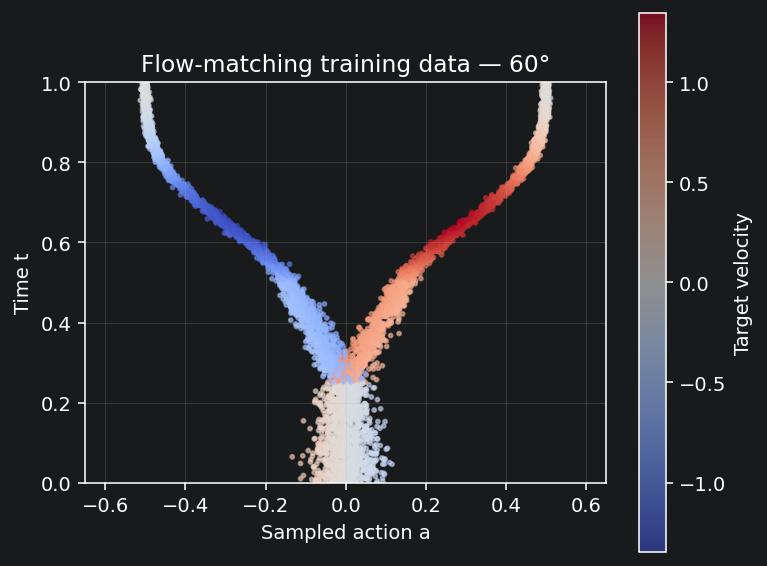

In [5]:
sanity_data = generate_flow_matching_data(
    angle_deg=60.0,
    num_samples=20_000,
    seed=0,
)

print("Input shape:", sanity_data["inputs"].shape)
print("Target shape:", sanity_data["targets"].shape)
print(
    "Left samples:",
    np.sum(sanity_data["modes"] == -1),
)
print(
    "Right samples:",
    np.sum(sanity_data["modes"] == +1),
)

plot_rng = np.random.default_rng(0)
plot_indices = plot_rng.choice(
    len(sanity_data["times"]),
    size=5000,
    replace=False,
)

plt.figure(figsize=(6, 5), dpi=140)

scatter = plt.scatter(
    sanity_data["sampled_actions"][plot_indices],
    sanity_data["times"][plot_indices],
    c=sanity_data["targets"][plot_indices, 0],
    cmap="coolwarm",
    s=4,
    alpha=0.6,
)

plt.colorbar(
    scatter,
    label="Target velocity",
)
plt.xlabel("Sampled action a")
plt.ylabel("Time t")
plt.title(
    "Flow-matching training data — 60°"
)
plt.xlim(-0.65, 0.65)
plt.ylim(0.0, 1.0)
plt.grid(alpha=0.2)
plt.gca().set_aspect(
    "equal",
    adjustable="box",
)
plt.show()

In [6]:
from torch.utils.data import DataLoader, TensorDataset


def set_random_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class VelocityMLP(nn.Module):
    """
    Learned velocity field:

        (action a, time t) -> velocity v
    """

    def __init__(
        self,
        hidden_dim: int = 128,
        num_hidden_layers: int = 4,
    ):
        super().__init__()

        layers = []
        input_dim = 2

        for _ in range(num_hidden_layers):
            layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.SiLU(),
            ])
            input_dim = hidden_dim

        layers.append(nn.Linear(hidden_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        action = inputs[:, 0]
        time = inputs[:, 1]

        # Normalize both inputs to roughly [-1, 1].
        normalized_inputs = torch.stack([
            action / goal_action,
            2.0 * time - 1.0,
        ], dim=1)

        return self.network(normalized_inputs)

In [7]:
def train_velocity_model(
    angle_deg: float,
    training_seed: int = 0,
    num_train_samples: int = 100_000,
    num_validation_samples: int = 20_000,
    batch_size: int = 2048,
    num_epochs: int = 50,
    learning_rate: float = 1e-3,
):
    set_random_seed(training_seed)

    train_data = generate_flow_matching_data(
        angle_deg=angle_deg,
        num_samples=num_train_samples,
        seed=training_seed,
    )

    validation_data = generate_flow_matching_data(
        angle_deg=angle_deg,
        num_samples=num_validation_samples,
        seed=training_seed + 10_000,
    )

    train_dataset = TensorDataset(
        torch.from_numpy(train_data["inputs"]),
        torch.from_numpy(train_data["targets"]),
    )

    validation_dataset = TensorDataset(
        torch.from_numpy(validation_data["inputs"]),
        torch.from_numpy(validation_data["targets"]),
    )

    loader_generator = torch.Generator()
    loader_generator.manual_seed(training_seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=loader_generator,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model = VelocityMLP(
        hidden_dim=128,
        num_hidden_layers=4,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-6,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,
    )

    loss_function = nn.MSELoss()

    history = {
        "train_loss": [],
        "validation_loss": [],
    }

    best_validation_loss = float("inf")
    best_state = None

    for epoch in range(1, num_epochs + 1):
        model.train()

        train_loss_sum = 0.0
        train_example_count = 0

        for batch_inputs, batch_targets in train_loader:
            batch_inputs = batch_inputs.to(
                device,
                non_blocking=True,
            )
            batch_targets = batch_targets.to(
                device,
                non_blocking=True,
            )

            optimizer.zero_grad(set_to_none=True)

            predictions = model(batch_inputs)
            loss = loss_function(
                predictions,
                batch_targets,
            )

            loss.backward()
            optimizer.step()

            batch_count = batch_inputs.shape[0]
            train_loss_sum += loss.item() * batch_count
            train_example_count += batch_count

        train_loss = (
            train_loss_sum / train_example_count
        )

        model.eval()

        validation_loss_sum = 0.0
        validation_example_count = 0

        with torch.no_grad():
            for batch_inputs, batch_targets in validation_loader:
                batch_inputs = batch_inputs.to(
                    device,
                    non_blocking=True,
                )
                batch_targets = batch_targets.to(
                    device,
                    non_blocking=True,
                )

                predictions = model(batch_inputs)
                loss = loss_function(
                    predictions,
                    batch_targets,
                )

                batch_count = batch_inputs.shape[0]
                validation_loss_sum += (
                    loss.item() * batch_count
                )
                validation_example_count += batch_count

        validation_loss = (
            validation_loss_sum
            / validation_example_count
        )

        history["train_loss"].append(train_loss)
        history["validation_loss"].append(
            validation_loss
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss

            best_state = {
                name: parameter.detach().cpu().clone()
                for name, parameter
                in model.state_dict().items()
            }

        scheduler.step()

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Angle {angle_deg:>4.0f}° | "
                f"Epoch {epoch:>3}/{num_epochs} | "
                f"train={train_loss:.6f} | "
                f"validation={validation_loss:.6f}"
            )

    model.load_state_dict(best_state)
    model.eval()

    print(
        f"\nBest validation loss: "
        f"{best_validation_loss:.6f}"
    )

    return model, history

In [8]:
model_60, history_60 = train_velocity_model(
    angle_deg=60.0,
    training_seed=0,
    num_train_samples=100_000,
    num_validation_samples=20_000,
    batch_size=2048,
    num_epochs=50,
    learning_rate=1e-3,
)

Angle   60° | Epoch   1/50 | train=0.261424 | validation=0.169250
Angle   60° | Epoch   5/50 | train=0.037667 | validation=0.036568
Angle   60° | Epoch  10/50 | train=0.034993 | validation=0.034099
Angle   60° | Epoch  15/50 | train=0.032755 | validation=0.031812
Angle   60° | Epoch  20/50 | train=0.025828 | validation=0.024643
Angle   60° | Epoch  25/50 | train=0.020537 | validation=0.019097
Angle   60° | Epoch  30/50 | train=0.017843 | validation=0.016594
Angle   60° | Epoch  35/50 | train=0.017235 | validation=0.016082
Angle   60° | Epoch  40/50 | train=0.017012 | validation=0.015895
Angle   60° | Epoch  45/50 | train=0.016918 | validation=0.015861
Angle   60° | Epoch  50/50 | train=0.016896 | validation=0.015814

Best validation loss: 0.015809


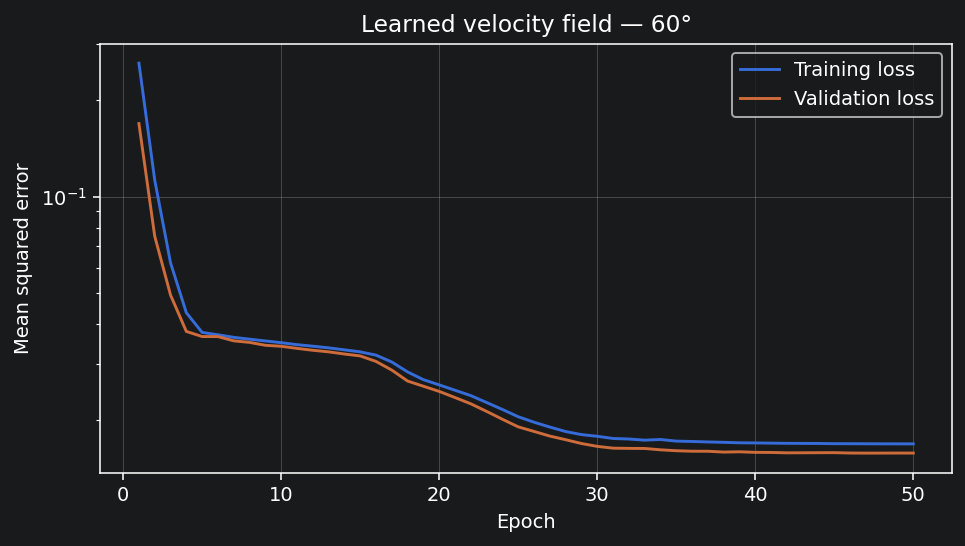

In [9]:
epochs = np.arange(
    1,
    len(history_60["train_loss"]) + 1,
)

plt.figure(figsize=(7, 4), dpi=140)

plt.plot(
    epochs,
    history_60["train_loss"],
    label="Training loss",
)

plt.plot(
    epochs,
    history_60["validation_loss"],
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("Learned velocity field — 60°")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
@torch.no_grad()
def integrate_learned_velocity(
    model: nn.Module,
    initial_actions: np.ndarray,
    num_steps: int = 1000,
    return_paths: bool = False,
):
    """
    Integrate da/dt = v_theta(a, t) using fourth-order
    Runge-Kutta integration (RK4).
    """
    model.eval()

    actions = torch.tensor(
        initial_actions,
        dtype=torch.float32,
        device=device,
    ).reshape(-1, 1)

    dt = 1.0 / num_steps

    if return_paths:
        path_history = [
            actions[:, 0].detach().cpu().numpy().copy()
        ]

    def evaluate_velocity(
        current_actions: torch.Tensor,
        current_times: torch.Tensor,
    ) -> torch.Tensor:
        model_inputs = torch.cat([
            current_actions,
            current_times,
        ], dim=1)

        return model(model_inputs)

    for step in range(num_steps):
        time_value = step * dt

        times_1 = torch.full_like(
            actions,
            time_value,
        )
        times_2 = torch.full_like(
            actions,
            time_value + 0.5 * dt,
        )
        times_4 = torch.full_like(
            actions,
            time_value + dt,
        )

        k1 = evaluate_velocity(
            actions,
            times_1,
        )

        k2 = evaluate_velocity(
            actions + 0.5 * dt * k1,
            times_2,
        )

        k3 = evaluate_velocity(
            actions + 0.5 * dt * k2,
            times_2,
        )

        k4 = evaluate_velocity(
            actions + dt * k3,
            times_4,
        )

        actions = actions + (
            dt / 6.0
        ) * (
            k1 + 2.0 * k2 + 2.0 * k3 + k4
        )

        if return_paths:
            path_history.append(
                actions[:, 0]
                .detach()
                .cpu()
                .numpy()
                .copy()
            )

    final_actions = (
        actions[:, 0]
        .detach()
        .cpu()
        .numpy()
    )

    if return_paths:
        paths = np.stack(
            path_history,
            axis=1,
        )
        return final_actions, paths

    return final_actions

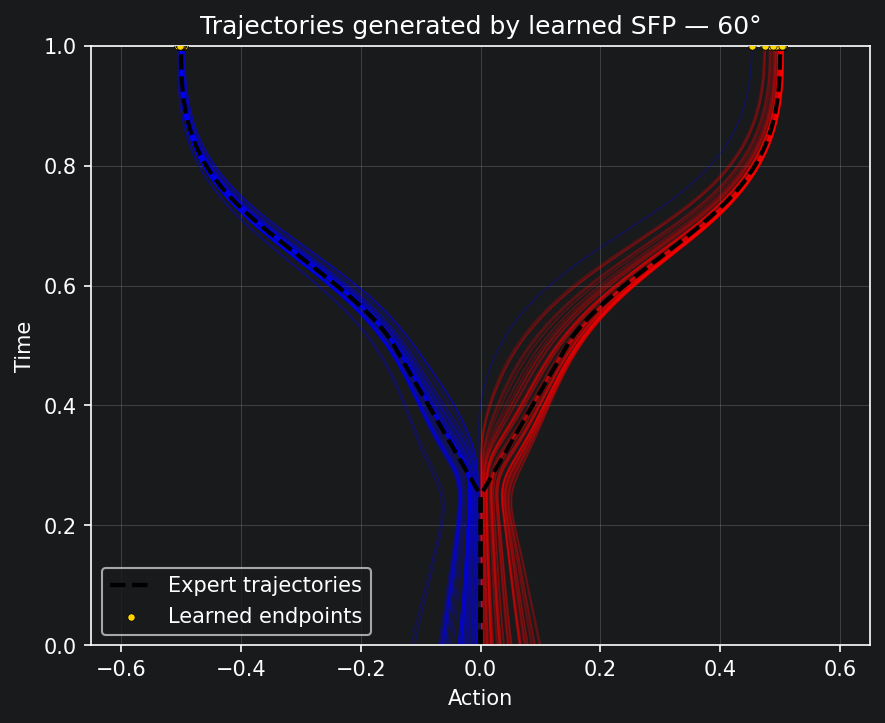

In [11]:
trajectory_rng = np.random.default_rng(0)

plot_initial_actions = trajectory_rng.normal(
    loc=0.0,
    scale=sigma_0,
    size=100,
)

plot_final_actions, learned_paths = (
    integrate_learned_velocity(
        model=model_60,
        initial_actions=plot_initial_actions,
        num_steps=1000,
        return_paths=True,
    )
)

plot_times = np.linspace(
    0.0,
    1.0,
    learned_paths.shape[1],
)

expert_right = make_demonstration_trajectory(
    sign=+1.0,
    angle_deg=60.0,
)
expert_left = make_demonstration_trajectory(
    sign=-1.0,
    angle_deg=60.0,
)

expert_times = np.linspace(0.0, 1.0, 500)

plt.figure(figsize=(6, 5), dpi=150)

for initial_action, path in zip(
    plot_initial_actions,
    learned_paths,
):
    color = (
        "red"
        if initial_action > 0
        else "blue"
    )

    plt.plot(
        path,
        plot_times,
        color=color,
        linewidth=0.8,
        alpha=0.25,
    )

# Expert trajectories are shown as black dashed lines.
plt.plot(
    expert_right.vector_values(expert_times)[0],
    expert_times,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Expert trajectories",
)

plt.plot(
    expert_left.vector_values(expert_times)[0],
    expert_times,
    color="black",
    linestyle="--",
    linewidth=2,
)

plt.scatter(
    plot_final_actions,
    np.ones_like(plot_final_actions),
    s=12,
    color="gold",
    edgecolor="black",
    linewidth=0.3,
    zorder=3,
    label="Learned endpoints",
)

plt.xlabel("Action")
plt.ylabel("Time")
plt.title("Trajectories generated by learned SFP — 60°")
plt.xlim(-0.65, 0.65)
plt.ylim(0.0, 1.0)
plt.grid(alpha=0.25)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
evaluation_rng = np.random.default_rng(0)

test_initial_actions = evaluation_rng.normal(
    loc=0.0,
    scale=sigma_0,
    size=1000,
)

learned_final_actions = integrate_learned_velocity(
    model=model_60,
    initial_actions=test_initial_actions,
    num_steps=1000,
    return_paths=False,
)

learned_endpoint_errors = np.minimum(
    np.abs(learned_final_actions - goal_action),
    np.abs(learned_final_actions + goal_action),
)

learned_sign_preservation = (
    np.sign(learned_final_actions)
    == np.sign(test_initial_actions)
)

print("Learned SFP evaluation — 60°")
print("--------------------------------")
print(
    f"Success@0.01: "
    f"{np.mean(learned_endpoint_errors <= 0.01):.2%}"
)
print(
    f"Success@0.05: "
    f"{np.mean(learned_endpoint_errors <= 0.05):.2%}"
)
print(
    f"Mean error:  "
    f"{np.mean(learned_endpoint_errors):.6f}"
)
print(
    f"Median error:"
    f" {np.median(learned_endpoint_errors):.6f}"
)
print(
    f"P95 error:   "
    f"{np.quantile(learned_endpoint_errors, 0.95):.6f}"
)
print(
    f"Max error:   "
    f"{np.max(learned_endpoint_errors):.6f}"
)
print(
    f"Right mode:  "
    f"{np.mean(learned_final_actions > 0):.2%}"
)
print(
    f"Sign kept:   "
    f"{np.mean(learned_sign_preservation):.2%}"
)

Learned SFP evaluation — 60°
--------------------------------
Success@0.01: 89.30%
Success@0.05: 97.20%
Mean error:  0.006654
Median error: 0.002186
P95 error:   0.024523
Max error:   0.446521
Right mode:  49.40%
Sign kept:   97.20%


In [13]:
practical_failure_mask = (
    learned_endpoint_errors > 0.05
)

strict_failure_mask = (
    learned_endpoint_errors > 0.01
)

mode_switch_mask = (
    np.sign(learned_final_actions)
    != np.sign(test_initial_actions)
)

print("Failure diagnostics — learned 60° model")
print("-----------------------------------------")
print(
    "Practical failures:",
    practical_failure_mask.sum(),
)
print(
    "Strict failures:",
    strict_failure_mask.sum(),
)
print(
    "Mode switches:",
    mode_switch_mask.sum(),
)

if practical_failure_mask.any():
    print(
        "Median |initial action| among practical failures:",
        f"{np.median(np.abs(test_initial_actions[practical_failure_mask])):.6f}",
    )
    print(
        "Largest |initial action| among practical failures:",
        f"{np.max(np.abs(test_initial_actions[practical_failure_mask])):.6f}",
    )

print(
    "Median |initial action| among successes:",
    f"{np.median(np.abs(test_initial_actions[~practical_failure_mask])):.6f}",
)

Failure diagnostics — learned 60° model
-----------------------------------------
Practical failures: 28
Strict failures: 107
Mode switches: 28
Median |initial action| among practical failures: 0.001706
Largest |initial action| among practical failures: 0.003208
Median |initial action| among successes: 0.033806


In [24]:
absolute_initial_actions = np.abs(
    test_initial_actions
)

initial_action_bins = [
    0.000,
    0.0025,
    0.005,
    0.010,
    0.020,
    0.040,
    np.inf,
]

print("\nSuccess rate by |initial action|")
print("------------------------------------------")
print(
    f"{'Range':>17} "
    f"{'Count':>8} "
    f"{'Success@.05':>13} "
    f"{'Mean error':>12}"
)

for lower, upper in zip(
    initial_action_bins[:-1],
    initial_action_bins[1:],
):
    bin_mask = (
        (absolute_initial_actions >= lower)
        & (absolute_initial_actions < upper)
    )

    count = bin_mask.sum()

    if count == 0:
        continue

    upper_label = (
        "inf"
        if np.isinf(upper)
        else f"{upper:.4f}"
    )

    success_rate = np.mean(
        learned_endpoint_errors[bin_mask] <= 0.05
    )

    mean_error = np.mean(
        learned_endpoint_errors[bin_mask]
    )

    print(
        f"[{lower:.4f}, {upper_label:>6}) "
        f"{count:>8} "
        f"{success_rate:>12.2%} "
        f"{mean_error:>12.6f}"
    )


Success rate by |initial action|
------------------------------------------
            Range    Count   Success@.05   Mean error
[0.0000, 0.0025)       40       50.00%     0.061199
[0.0025, 0.0050)       33       75.76%     0.050757
[0.0050, 0.0100)       85      100.00%     0.008225
[0.0100, 0.0200)      173      100.00%     0.003301
[0.0200, 0.0400)      268      100.00%     0.000690
[0.0400,    inf)      401      100.00%     0.002684


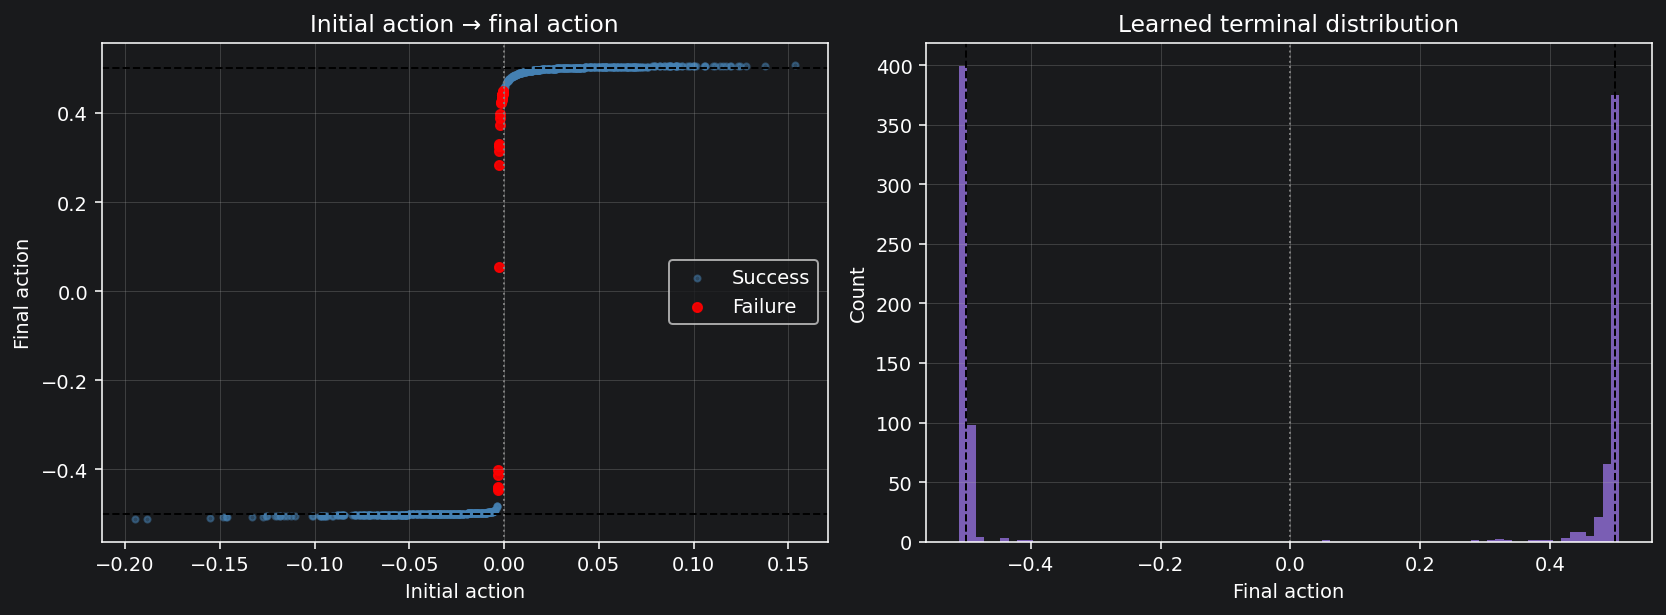

In [15]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    dpi=140,
)

# Initial action versus final action
axes[0].scatter(
    test_initial_actions[~practical_failure_mask],
    learned_final_actions[~practical_failure_mask],
    s=10,
    alpha=0.45,
    color="steelblue",
    label="Success",
)

axes[0].scatter(
    test_initial_actions[practical_failure_mask],
    learned_final_actions[practical_failure_mask],
    s=22,
    alpha=0.9,
    color="red",
    label="Failure",
)

axes[0].axhline(
    +goal_action,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0].axhline(
    -goal_action,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0].axvline(
    0.0,
    color="gray",
    linestyle=":",
    linewidth=1,
)

axes[0].set_xlabel("Initial action")
axes[0].set_ylabel("Final action")
axes[0].set_title("Initial action → final action")
axes[0].grid(alpha=0.25)
axes[0].legend()

# Endpoint histogram
axes[1].hist(
    learned_final_actions,
    bins=80,
    color="mediumpurple",
    alpha=0.8,
)

axes[1].axvline(
    +goal_action,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[1].axvline(
    -goal_action,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[1].axvline(
    0.0,
    color="gray",
    linestyle=":",
    linewidth=1,
)

axes[1].set_xlabel("Final action")
axes[1].set_ylabel("Count")
axes[1].set_title("Learned terminal distribution")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [16]:
learned_models = {
    60.0: model_60,
}

training_histories = {
    60.0: history_60,
}

for angle in [20.0, 40.0, 80.0]:
    print("\n" + "=" * 70)
    print(f"Training learned SFP for {angle:.0f}°")
    print("=" * 70)

    model, history = train_velocity_model(
        angle_deg=angle,
        training_seed=0,
        num_train_samples=100_000,
        num_validation_samples=20_000,
        batch_size=2048,
        num_epochs=50,
        learning_rate=1e-3,
    )

    learned_models[angle] = model
    training_histories[angle] = history


Training learned SFP for 20°
Angle   20° | Epoch   1/50 | train=0.504975 | validation=0.403494
Angle   20° | Epoch   5/50 | train=0.017346 | validation=0.017360
Angle   20° | Epoch  10/50 | train=0.015109 | validation=0.015182
Angle   20° | Epoch  15/50 | train=0.011489 | validation=0.011038
Angle   20° | Epoch  20/50 | train=0.008256 | validation=0.007869
Angle   20° | Epoch  25/50 | train=0.006770 | validation=0.006466
Angle   20° | Epoch  30/50 | train=0.006185 | validation=0.005956
Angle   20° | Epoch  35/50 | train=0.005899 | validation=0.005674
Angle   20° | Epoch  40/50 | train=0.005755 | validation=0.005537
Angle   20° | Epoch  45/50 | train=0.005692 | validation=0.005476
Angle   20° | Epoch  50/50 | train=0.005678 | validation=0.005465

Best validation loss: 0.005465

Training learned SFP for 40°
Angle   40° | Epoch   1/50 | train=0.363541 | validation=0.266173
Angle   40° | Epoch   5/50 | train=0.024571 | validation=0.022935
Angle   40° | Epoch  10/50 | train=0.021235 | vali

In [17]:
def evaluate_learned_model(
    model: nn.Module,
    initial_actions: np.ndarray,
    ode_steps: int = 1000,
) -> dict:
    final_actions = integrate_learned_velocity(
        model=model,
        initial_actions=initial_actions,
        num_steps=ode_steps,
        return_paths=False,
    )

    endpoint_errors = np.minimum(
        np.abs(final_actions - goal_action),
        np.abs(final_actions + goal_action),
    )

    sign_preservation = (
        np.sign(final_actions)
        == np.sign(initial_actions)
    )

    near_center_mask = (
        np.abs(initial_actions) < 0.01
    )

    practical_failure_mask = (
        endpoint_errors > 0.05
    )

    if practical_failure_mask.any():
        largest_failed_initial = np.max(
            np.abs(
                initial_actions[
                    practical_failure_mask
                ]
            )
        )
    else:
        largest_failed_initial = 0.0

    return {
        "success_001": np.mean(
            endpoint_errors <= 0.01
        ),
        "success_005": np.mean(
            endpoint_errors <= 0.05
        ),
        "mean_error": np.mean(endpoint_errors),
        "p95_error": np.quantile(
            endpoint_errors,
            0.95,
        ),
        "max_error": np.max(endpoint_errors),
        "right_fraction": np.mean(
            final_actions > 0
        ),
        "sign_preservation": np.mean(
            sign_preservation
        ),
        "near_center_success": np.mean(
            endpoint_errors[near_center_mask]
            <= 0.05
        ),
        "largest_failed_initial": (
            largest_failed_initial
        ),
        "final_actions": final_actions,
        "endpoint_errors": endpoint_errors,
    }

In [18]:
comparison_rng = np.random.default_rng(0)

shared_test_initial_actions = comparison_rng.normal(
    loc=0.0,
    scale=sigma_0,
    size=1000,
)

learned_results = {}

for angle in evaluation_angles:
    print(f"Evaluating {angle:.0f}°...")

    learned_results[angle] = evaluate_learned_model(
        model=learned_models[angle],
        initial_actions=shared_test_initial_actions,
        ode_steps=1000,
    )

Evaluating 20°...
Evaluating 40°...
Evaluating 60°...
Evaluating 80°...


In [19]:
header = (
    f"{'Angle':>7} "
    f"{'Val loss':>10} "
    f"{'Succ@.01':>10} "
    f"{'Succ@.05':>10} "
    f"{'Mean err':>10} "
    f"{'P95 err':>10} "
    f"{'Center succ':>12} "
    f"{'Fail width':>11} "
    f"{'Sign kept':>11}"
)

print(header)
print("-" * len(header))

for angle in evaluation_angles:
    result = learned_results[angle]

    best_validation_loss = min(
        training_histories[angle][
            "validation_loss"
        ]
    )

    print(
        f"{angle:>6.0f}° "
        f"{best_validation_loss:>10.6f} "
        f"{result['success_001']:>9.2%} "
        f"{result['success_005']:>9.2%} "
        f"{result['mean_error']:>10.6f} "
        f"{result['p95_error']:>10.6f} "
        f"{result['near_center_success']:>11.2%} "
        f"{result['largest_failed_initial']:>11.6f} "
        f"{result['sign_preservation']:>10.2%}"
    )

  Angle   Val loss   Succ@.01   Succ@.05   Mean err    P95 err  Center succ  Fail width   Sign kept
---------------------------------------------------------------------------------------------------
    20°   0.005465    72.00%    90.00%   0.022725   0.107429      36.71%    0.008841     99.50%
    40°   0.013615    69.50%    95.40%   0.013000   0.045898      70.89%    0.006169     99.80%
    60°   0.015809    89.30%    97.20%   0.006654   0.024523      82.28%    0.003208     97.20%
    80°   0.021709    77.40%    95.00%   0.018474   0.049258      68.35%    0.005082     99.10%


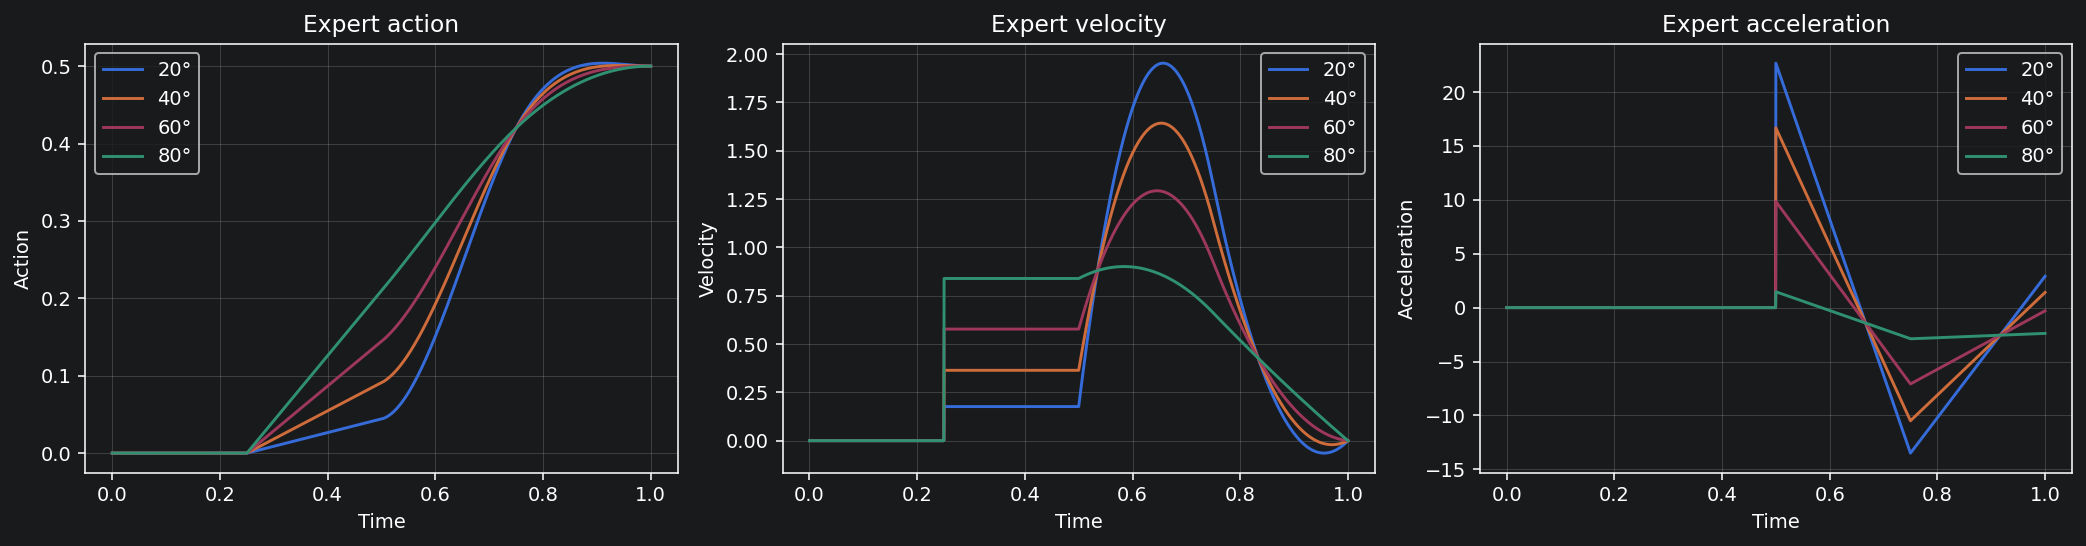

In [20]:
geometry_times = np.linspace(
    0.0,
    1.0,
    2001,
)

geometry_results = {}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    dpi=140,
)

for angle in evaluation_angles:
    trajectory = make_demonstration_trajectory(
        sign=+1.0,
        angle_deg=angle,
    )

    velocity_trajectory = (
        trajectory.MakeDerivative()
    )
    acceleration_trajectory = (
        velocity_trajectory.MakeDerivative()
    )

    positions = trajectory.vector_values(
        geometry_times
    )[0]

    velocities = (
        velocity_trajectory.vector_values(
            geometry_times
        )[0]
    )

    accelerations = (
        acceleration_trajectory.vector_values(
            geometry_times
        )[0]
    )

    path_length = np.trapezoid(
        np.abs(velocities),
        geometry_times,
    )

    acceleration_energy = np.trapezoid(
        accelerations ** 2,
        geometry_times,
    )

    geometry_results[angle] = {
        "path_length": path_length,
        "max_speed": np.max(
            np.abs(velocities)
        ),
        "max_acceleration": np.max(
            np.abs(accelerations)
        ),
        "acceleration_energy": (
            acceleration_energy
        ),
    }

    axes[0].plot(
        geometry_times,
        positions,
        label=f"{angle:.0f}°",
    )
    axes[1].plot(
        geometry_times,
        velocities,
        label=f"{angle:.0f}°",
    )
    axes[2].plot(
        geometry_times,
        accelerations,
        label=f"{angle:.0f}°",
    )

axes[0].set_title("Expert action")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Action")

axes[1].set_title("Expert velocity")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Velocity")

axes[2].set_title("Expert acceleration")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Acceleration")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

In [21]:
header = (
    f"{'Angle':>7} "
    f"{'Path length':>13} "
    f"{'Max speed':>11} "
    f"{'Max accel':>11} "
    f"{'Accel energy':>14}"
)

print(header)
print("-" * len(header))

for angle in evaluation_angles:
    result = geometry_results[angle]

    print(
        f"{angle:>6.0f}° "
        f"{result['path_length']:>13.6f} "
        f"{result['max_speed']:>11.6f} "
        f"{result['max_acceleration']:>11.6f} "
        f"{result['acceleration_energy']:>14.6f}"
    )

  Angle   Path length   Max speed   Max accel   Accel energy
------------------------------------------------------------
    20°      0.507666    1.953283   22.677537      45.276894
    40°      0.501733    1.642923   16.672953      25.947453
    60°      0.500144    1.293062    9.844791      10.834401
    80°      0.500210    0.900906    2.894406       2.276580


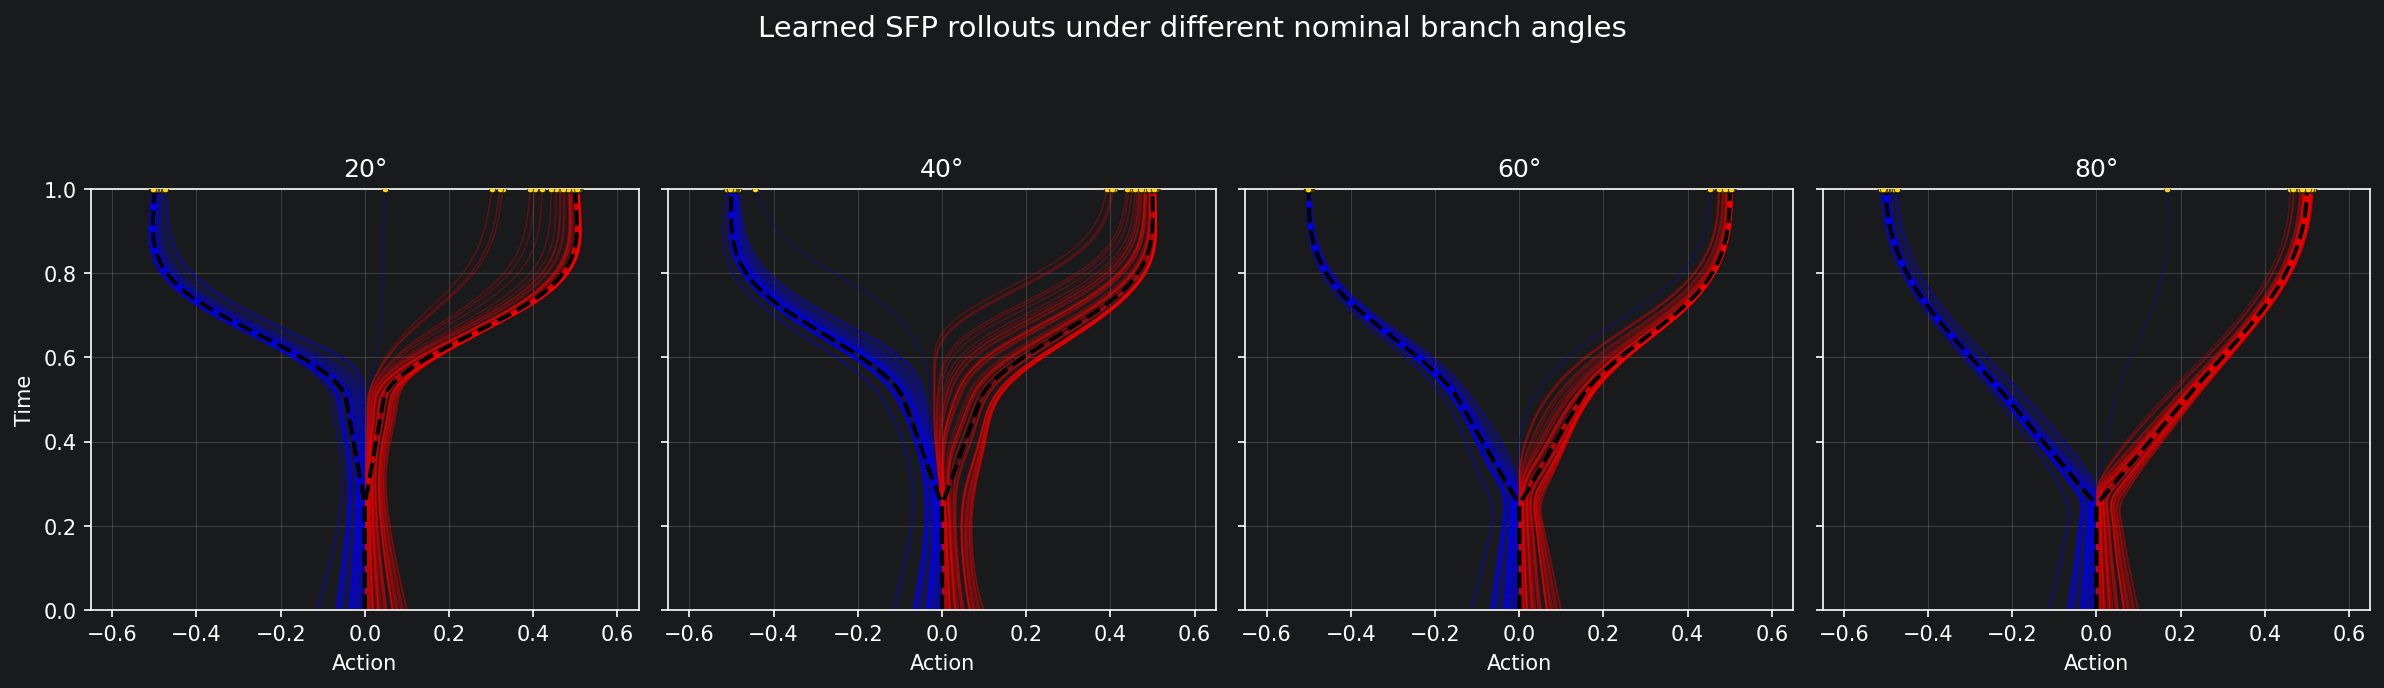

In [23]:
# Learned rollout visualization for all four branch angles

plot_angles = [20.0, 40.0, 60.0, 80.0]

trajectory_rng = np.random.default_rng(0)

# Use exactly the same initial actions for every angle
plot_initial_actions = trajectory_rng.normal(
    loc=0.0,
    scale=sigma_0,
    size=100,
)

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 5),
    dpi=150,
    sharex=True,
    sharey=True,
)

expert_times = np.linspace(
    0.0,
    goal_time,
    500,
)

for ax, angle in zip(axes, plot_angles):

    # --------------------------------------------------
    # 1. Generate learned rollouts
    # --------------------------------------------------

    plot_final_actions, learned_paths = (
        integrate_learned_velocity(
            model=learned_models[angle],
            initial_actions=plot_initial_actions,
            num_steps=1000,
            return_paths=True,
        )
    )

    plot_times = np.linspace(
        0.0,
        goal_time,
        learned_paths.shape[1],
    )

    # --------------------------------------------------
    # 2. Plot learned trajectories
    # --------------------------------------------------

    for initial_action, path in zip(
        plot_initial_actions,
        learned_paths,
    ):
        color = (
            "red"
            if initial_action > 0
            else "blue"
        )

        ax.plot(
            path,
            plot_times,
            color=color,
            linewidth=0.8,
            alpha=0.25,
        )

    # --------------------------------------------------
    # 3. Plot expert trajectories
    # --------------------------------------------------

    expert_right = make_demonstration_trajectory(
        sign=+1.0,
        angle_deg=angle,
    )

    expert_left = make_demonstration_trajectory(
        sign=-1.0,
        angle_deg=angle,
    )

    ax.plot(
        expert_right.vector_values(expert_times)[0],
        expert_times,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Expert",
    )

    ax.plot(
        expert_left.vector_values(expert_times)[0],
        expert_times,
        color="black",
        linestyle="--",
        linewidth=2,
    )

    # --------------------------------------------------
    # 4. Plot learned endpoints
    # --------------------------------------------------

    ax.scatter(
        plot_final_actions,
        np.ones_like(plot_final_actions) * goal_time,
        s=10,
        color="gold",
        edgecolor="black",
        linewidth=0.3,
        zorder=3,
    )

    # --------------------------------------------------
    # 5. Figure formatting
    # --------------------------------------------------

    ax.set_title(f"{angle:.0f}°")
    ax.set_xlabel("Action")

    ax.set_xlim(-0.65, 0.65)
    ax.set_ylim(0.0, goal_time)

    ax.grid(alpha=0.25)

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

axes[0].set_ylabel("Time")

fig.suptitle(
    "Learned SFP rollouts under different nominal branch angles",
    fontsize=14,
)

plt.tight_layout()
plt.show()